In [77]:
import pandas as pd
import glob
import matplotlib.pyplot as plt
import numpy as np
from calibration import lifetime_to_temperature_GPMV, lifetime_to_temperature_201112, lifetime_to_temperature_water_gel13
from scipy.optimize import curve_fit
import seaborn as sns
from PIL import Image
import scipy as sp
from draw_graph import Scatter
from matplotlib.backends.backend_pdf import PdfPages

In [78]:
files_path = glob.glob('./2108??_GPMV_lin22.6_32_PFADTT/10um/*.csv')
files_path.sort()

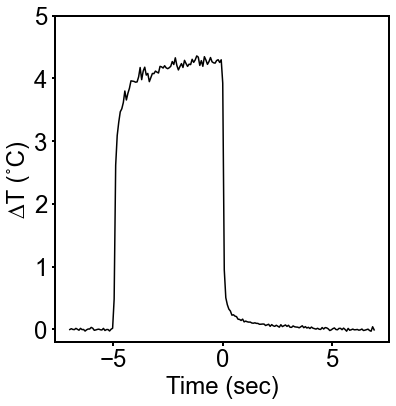

In [79]:
plt.figure(figsize = (6, 6))
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['xtick.major.width'] = 2.0
plt.rcParams['ytick.major.width'] = 2.0
plt.rcParams['axes.linewidth'] = 2.0
data_set_GPMV = pd.DataFrame()

#データの平均化
average = np.zeros((1, 200))
for path in files_path:
    df = pd.read_csv(path, sep = '\t')
    relaxation_int = np.array(df.iloc[1:, 3], dtype = 'float32')
    relaxation = np.array(df.iloc[1:, 1], dtype = 'float32')
    diff = relaxation_int[:-1] - relaxation_int[1:]
    off_time = np.argmax(diff)
    extract = lifetime_to_temperature_GPMV(relaxation[off_time-100 : off_time+100])
    average += extract
    data_set_GPMV = pd.concat([data_set_GPMV, pd.DataFrame(extract)], axis = 1)
average_GPMV = average[0]/len(files_path)
average_GPMV = average_GPMV - np.mean(average_GPMV[:10])
time = [(i-100)*0.07 for i in range(len(average_GPMV))]
plt.tick_params(axis='both', direction = "out", labelsize = 24)
plt.plot(time, average_GPMV, color = 'Black')
plt.ylim(-0.2, 5.0)
plt.xlabel('Time (sec)', fontsize = 24)
plt.ylabel('∆T (˚C)', fontsize = 24)
plt.show()

#データの保存
(data_set_GPMV - data_set_GPMV.iloc[:10, :].mean()).to_csv('GPMV_deltaT_all.csv')
pd.DataFrame(average_GPMV).to_csv('ave_GPMV.csv')

In [80]:
files_path = glob.glob('./continuous/2009??_IRheating_lin22.6_100mW_5000ms_26/cyto/*.csv')
files_path.sort()

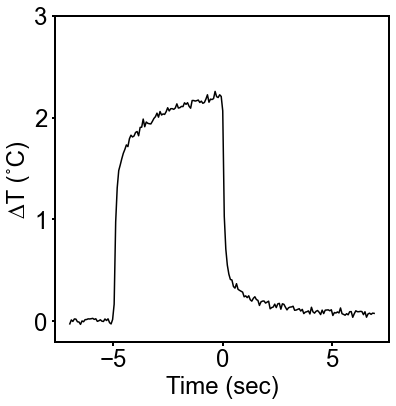

In [81]:
plt.figure(figsize = (6, 6))
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['xtick.major.width'] = 2.0
plt.rcParams['ytick.major.width'] = 2.0
plt.rcParams['axes.linewidth'] = 2.0
data_set_normal = pd.DataFrame()

#データの平均化
average = np.zeros((1, 200))
for path in files_path:
    df = pd.read_csv(path, sep = '\t')
    relaxation_int = np.array(df.iloc[1:, 3], dtype = 'float32')
    relaxation = np.array(df.iloc[1:, 1], dtype = 'float32')
    diff = relaxation_int[:-1] - relaxation_int[1:]
    off_time = np.argmax(diff)
    extract = lifetime_to_temperature_201112(relaxation[off_time-100 : off_time+100])
    average += extract
    data_set_normal = pd.concat([data_set_normal, pd.DataFrame(extract)], axis = 1)
average_normal = average[0]/len(files_path)
average_normal = average_normal - np.mean(average_normal[:10])
time = [(i-100)*0.07 for i in range(len(average_normal))]
plt.tick_params(axis='both', direction = "out", labelsize = 24)
plt.plot(time, average_normal, color = 'Black')
plt.ylim(-0.2, 3.0)
plt.xlabel('Time (sec)', fontsize = 24)
plt.ylabel('∆T (˚C)', fontsize = 24)
plt.show()

#データの保存
(data_set_normal - data_set_normal.iloc[:10, :].mean()).to_csv('cell_deltaT_all.csv')
pd.DataFrame(average_normal).to_csv('ave_cell.csv')

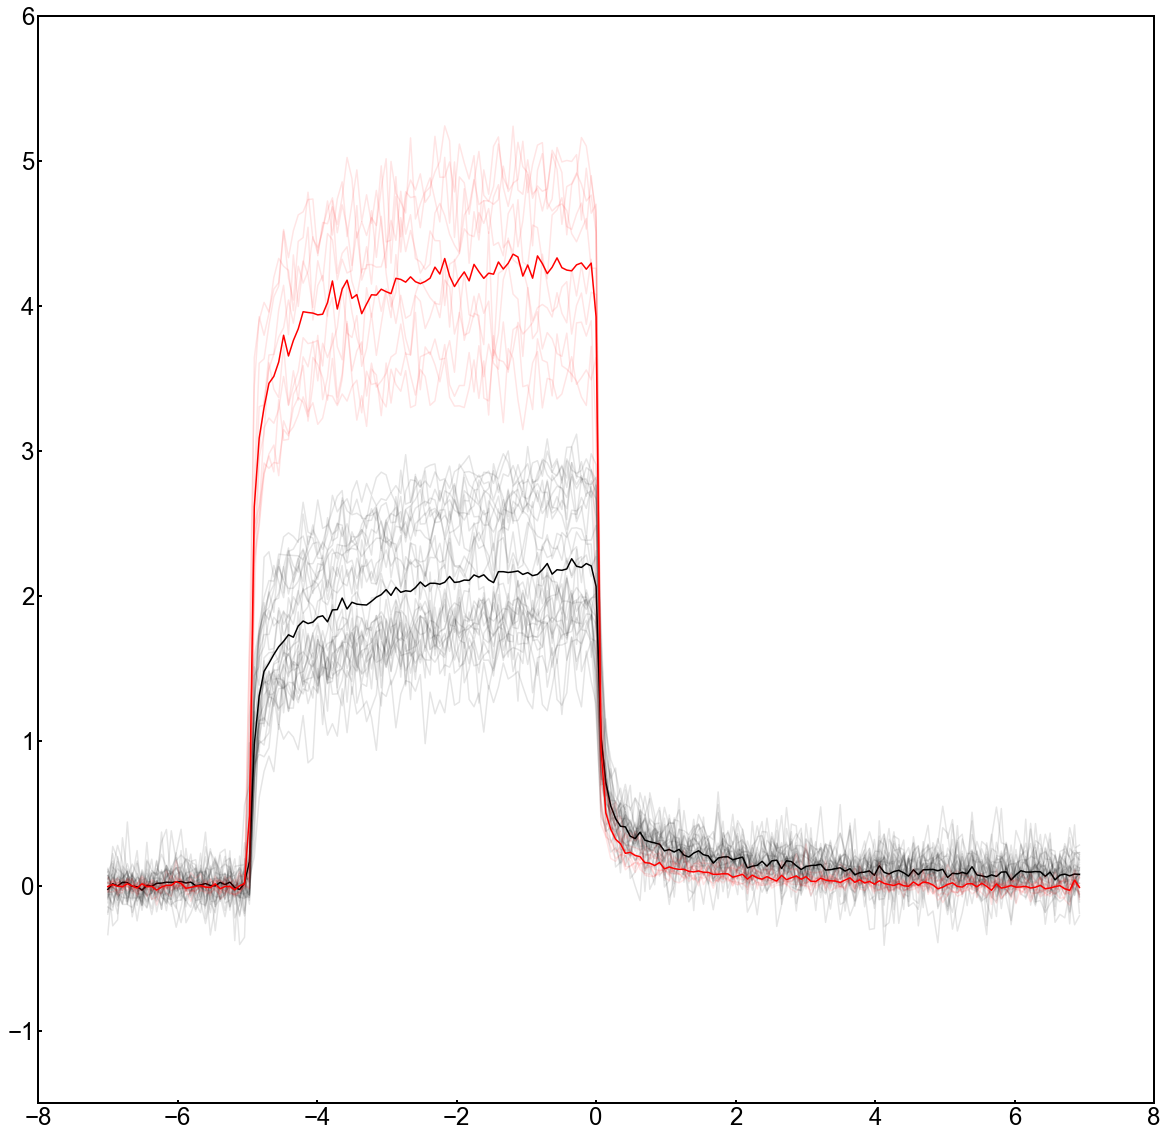

In [82]:
fig = plt.figure(figsize = (20, 20))
plt.tick_params(axis='both', direction = "in", labelsize = 24)
time = [(i-100)*0.07 for i in range(len(average_normal))]
plt.plot(time, average_normal, color = 'black')
plt.plot(time, data_set_normal - data_set_normal.iloc[:10, :].mean(), color = 'black', alpha = 0.1)
plt.plot(time, average_GPMV, color = 'red')
plt.plot(time, data_set_GPMV - data_set_GPMV.iloc[:10, :].mean(), color = 'red', alpha = 0.1)
plt.xlim(-8, 8)
plt.ylim(-1.5, 6)
plt.show()

#pdfのセーブ
pp = PdfPages('./FigS15_deltaT.pdf')
pp.savefig(fig)
pp.close()

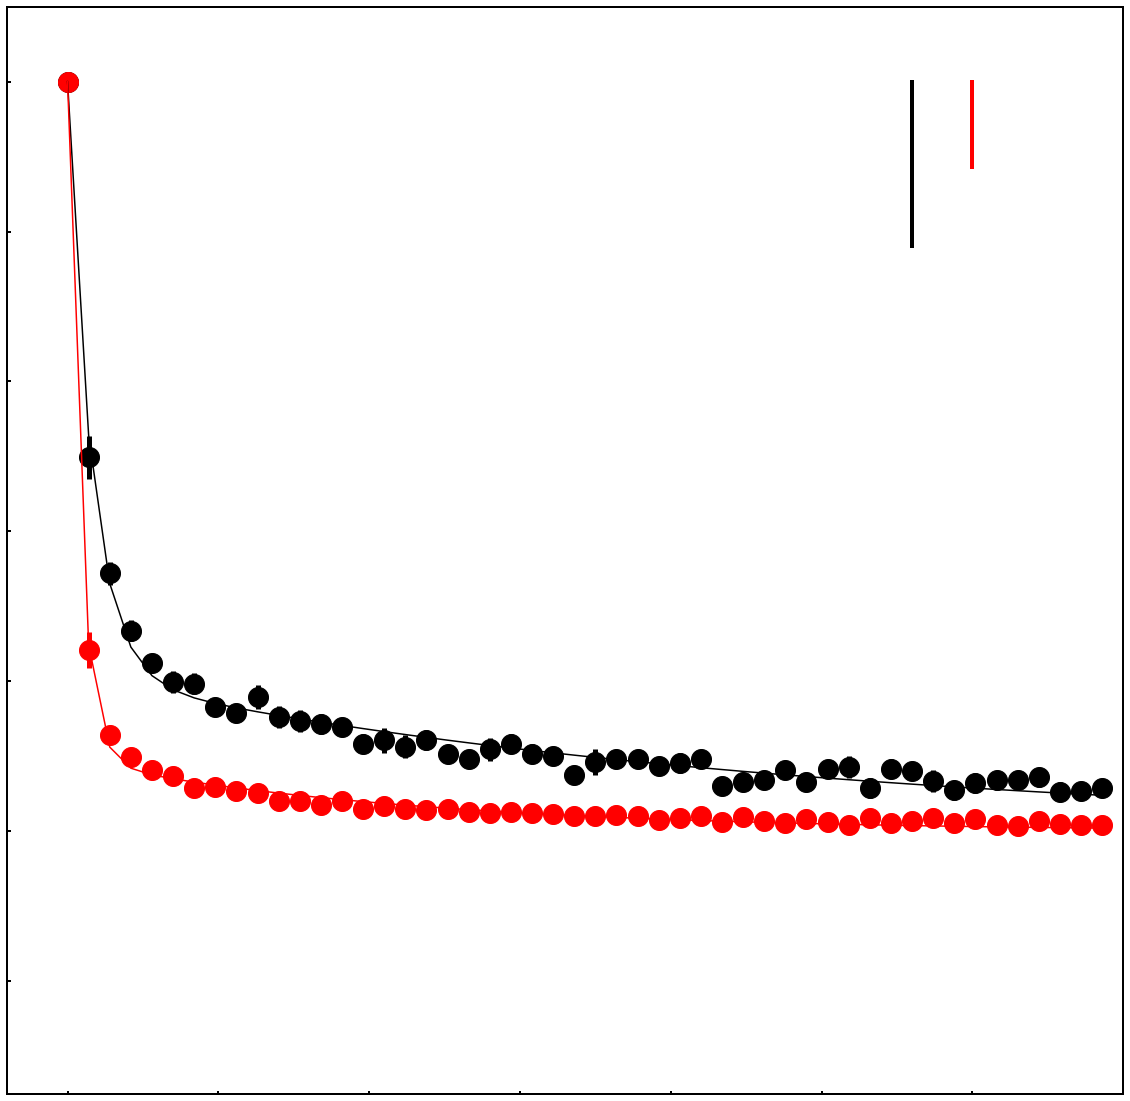

In [83]:
#実測データのプロット
fig = plt.figure(figsize = (20, 20))
plt.tick_params(axis='both', direction = "in", labelsize = 24)
time_GPMV = [(i)*0.07 for i in range(len(average_GPMV[100:150]))]
time_normal = [(i)*0.07 for i in range(len(average_normal[100:150]))]


#SEMの計算
data_set_normal = data_set_normal - np.mean(data_set_normal.iloc[:10, :])
data_set_normal = data_set_normal/data_set_normal.iloc[50, :]*100
sem_normal = data_set_normal.sem(axis = 1)
sem_normal[100] = 0

data_set_GPMV = data_set_GPMV - np.mean(data_set_GPMV.iloc[:10, :])
data_set_GPMV = data_set_GPMV/data_set_GPMV.iloc[100, :]*100
sem_GPMV = data_set_GPMV.sem(axis = 1)
sem_GPMV[100] = 0



#1˚Cを示すバーを挿入
GPMV_bar = [100 - 50/max(average_GPMV)*i/100 for i in range(100)]
GPMV_bar_pos = [3.0 for i in range(len(GPMV_bar))]
plt.plot(GPMV_bar_pos, GPMV_bar, linewidth = 4, color = 'red', linestyle = '-')

#1˚Cを示すバーを挿入
normal_bar = [100 - 50/max(average_normal)*i/100 for i in range(100)]
normal_bar_pos = [2.8 for i in range(len(normal_bar))]
plt.plot(normal_bar_pos, normal_bar, linewidth = 4, color = 'black', linestyle = '-')



average_GPMV = average_GPMV/average_GPMV[100]
average_normal = average_normal/average_normal[100]

plt.errorbar(time_normal, average_normal[100:150]*100/average_normal[100], yerr = np.ravel(sem_normal)[100:150], capsize=0, fmt='o', markersize=0, linewidth = 5, ecolor='black')
plt.errorbar(time_GPMV, average_GPMV[100:150]*100/average_GPMV[100], yerr = np.ravel(sem_GPMV)[100:150], capsize=0, fmt='o', markersize=0, linewidth = 5, ecolor='red')
plt.plot(time_normal, average_normal[100:150]*100/average_normal[100], color = 'black', markersize = 20, marker = 'o', linewidth = 0)
plt.plot(time_GPMV, average_GPMV[100:150]*100/average_GPMV[100], color = 'red', markersize = 20, marker = 'o', linewidth = 0)
#plt.ylim(-20, 120)
#plt.xlabel('Time (sec)', fontsize = 24)
#plt.ylabel('Temperature change rate \n(%, 100% at 0sec)', fontsize = 24)
plt.tick_params(labelbottom=False,
                labelleft=False,
                labelright=False,
                labeltop=False)



#温度緩和の時定数の計算
def relaxation(time, ratio, t1, t2):
    return ratio*np.exp(-time/t1) + (1-ratio)*np.exp(-time/t2)
result_GPMV = curve_fit(relaxation, time_GPMV, average_GPMV[100:150])[0]
result_normal = curve_fit(relaxation, time_normal, average_normal[100:150])[0]


plt.xlim(-0.2, 3.5)
plt.ylim(-35, 110)

#fitting結果の図示
plt.plot(time_normal, relaxation(np.ravel(time_normal), result_normal[0], result_normal[1], result_normal[2])*100, color = 'black')
plt.plot(time_GPMV, relaxation(np.ravel(time_GPMV), result_GPMV[0], result_GPMV[1], result_GPMV[2])*100, color = 'red')

#pdfのセーブ
pp = PdfPages('./FigS15_normed.pdf')
pp.savefig(fig)
pp.close()

#データの保存
pd.DataFrame(average_normal[100:150]*100/average_normal[100]).to_csv('normed_cell.csv')
pd.DataFrame(average_GPMV[100:150]*100/average_GPMV[100]).to_csv('normed_GPMV.csv')
(sem_normal)[100:150].to_csv('sem_cell.csv')
(sem_GPMV)[100:150].to_csv('sem_GPMV.csv')

In [84]:
#welchのt検定
sum_normal = data_set_normal.iloc[102:150].sum().values
sum_GPMV = data_set_GPMV.iloc[102:150].sum().values
sp.stats.ttest_ind(sum_normal, sum_GPMV, equal_var = False)

Ttest_indResult(statistic=15.475643056083843, pvalue=2.5475377331667203e-17)

In [85]:
sem_normal_bar = (sum_normal*0.07).std(ddof = 1)/np.sqrt(len(sum_normal))
sem_GPMV_bar = (sum_GPMV*0.07).std(ddof = 1)/np.sqrt(len(sum_GPMV))

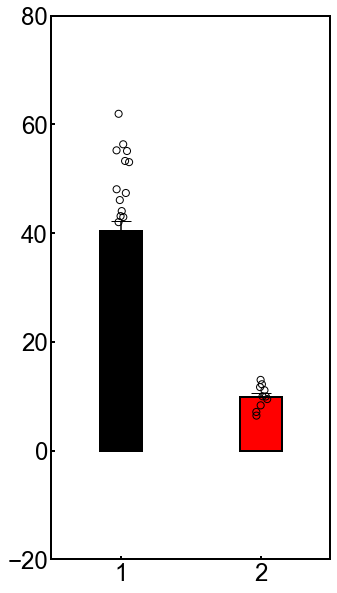

In [86]:
fig = plt.figure(figsize = (5, 10))
plt.tick_params(axis='both', direction = "in", labelsize = 24)
sum_normal_ave = np.average(sum_normal*0.07)
sum_GPMV_ave = np.average(sum_GPMV*0.07)
plt.bar(1, sum_normal_ave, yerr = [[0], [sem_normal_bar]], capsize = 10, ecolor = 'black', width=0.3, color=(0, 0, 0, 1), edgecolor='black', linewidth = 2, zorder = 1)
x = np.random.normal(1, 0.03, size=len(sum_normal)) 
plt.scatter(x, sum_normal*0.07, color='none', edgecolor='black', alpha = 1, s=50, zorder = 2)
plt.bar(2, sum_GPMV_ave, yerr = [[0], [sem_GPMV_bar]], capsize = 10, ecolor = 'black', width=0.3, color=(1, 0, 0, 1), edgecolor='black', linewidth = 2, zorder = 1)
x = np.random.normal(2, 0.03, size=len(sum_GPMV)) 
plt.scatter(x, sum_GPMV*0.07, color='none', edgecolor='black', alpha = 1, s=50, zorder = 2)


plt.ylim(-20, 80)
plt.xlim(0.5, 2.5)

#pdfのセーブ
pp = PdfPages('./FigS15_AUC.pdf')
pp.savefig(fig)
pp.close()

#データの保存
pd.DataFrame(sum_normal*0.07).to_csv('AUC_cell.csv')
pd.DataFrame(sum_GPMV*0.07).to_csv('AUC_GPMV.csv')

In [87]:
print(sum_normal_ave)
print(sum_GPMV_ave)

40.34818
9.926619


In [88]:
print(sem_normal_bar)
print(sem_GPMV_bar)

1.84325116878848
0.6831384039209613
